In [1]:
import sympy
from mira.sources.sympy_ode import template_model_from_sympy_odes

In [2]:
# Define time variable
t = sympy.symbols("t")

# Define the time-dependent variables
S, E, I, R = sympy.symbols("S E I R", cls=sympy.Function)

# Define the parameters
b, g, r = sympy.symbols("b g r")

odes = [
    sympy.Eq(S(t).diff(t), - b * S(t) * I(t)),
    sympy.Eq(E(t).diff(t), b * S(t) * I(t) - r * E(t)),
    sympy.Eq(I(t).diff(t), r * E(t) - g * I(t)),
    sympy.Eq(R(t).diff(t), g * I(t))
]

In [3]:
# tm = template_model_from_sympy_odes(odes, concept_data=concept_data)
tm = template_model_from_sympy_odes(odes)

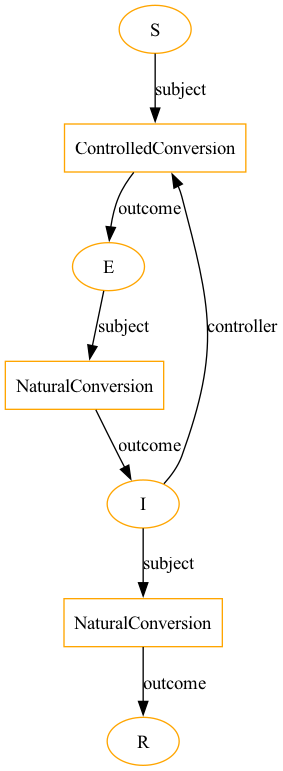

In [4]:
tm.draw_jupyter()

In [5]:
from sympy import symbols, Eq, Function

# Define time variable and functions for compartments
t = symbols('t')
S, E, V, I, T, H, R = Function('S')(t), Function('E')(t), Function('V')(t), Function('I')(t), Function('T')(t), Function('H')(t), Function('R')(t)

# Define parameters as constants
lambda_0, epsilon_V, p_T, sigma, delta, eta, kappa = symbols('lambda epsilon_V p_T sigma delta eta kappa')

# Define the system of differential equations
odes2 = [
    Eq(S.diff(t), -lambda_0 * S),
    Eq(E.diff(t), lambda_0 * S + epsilon_V * lambda_0 * V - p_T * sigma * E - (1 - p_T) * sigma * E),
    Eq(V.diff(t), -epsilon_V * lambda_0 * V),
    Eq(I.diff(t), (1 - p_T) * sigma * E - (delta + eta) * I),
    Eq(T.diff(t), p_T * sigma * E - delta * T),
    Eq(H.diff(t), eta * I - kappa * H),
    Eq(R.diff(t), delta * I + delta * T + kappa * H)
]


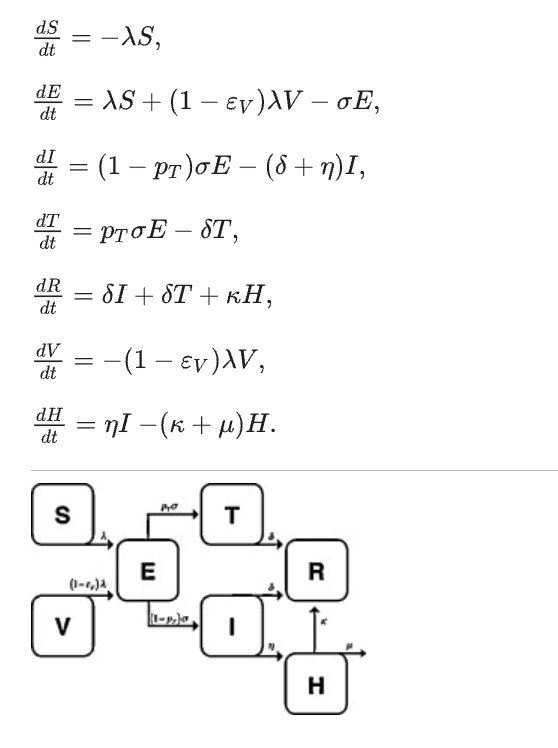

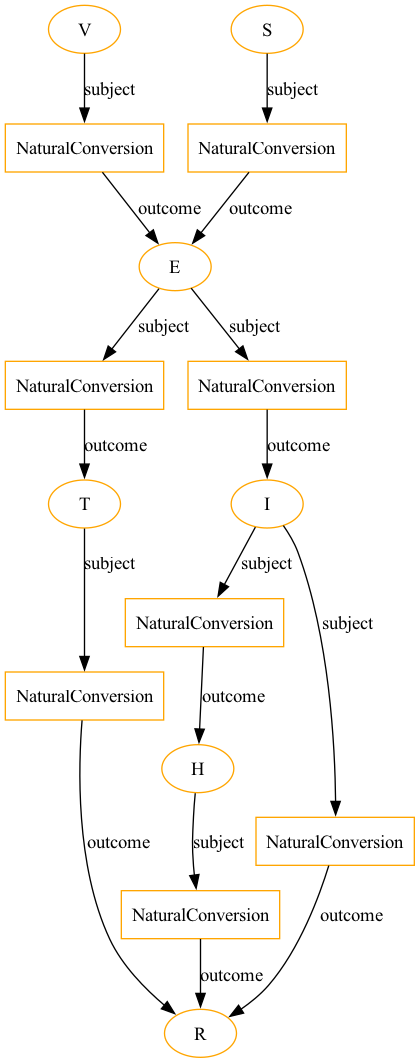

In [6]:
tm = template_model_from_sympy_odes(odes2)
tm.draw_jupyter()

In [7]:
odes2 = [
    Eq(S.diff(t), -lambda_0 * S),
    Eq(E.diff(t), lambda_0 * S + epsilon_V * lambda_0 * V - p_T * sigma * E - (1 - p_T) * sigma * E),
    Eq(V.diff(t), -epsilon_V * lambda_0 * V),
    Eq(I.diff(t), (1 - p_T) * sigma * E - delta * I - eta * I),
    Eq(T.diff(t), p_T * sigma * E - delta * T),
    Eq(H.diff(t), eta * I - kappa * H),
    Eq(R.diff(t), delta * I + delta * T + kappa * H)
]

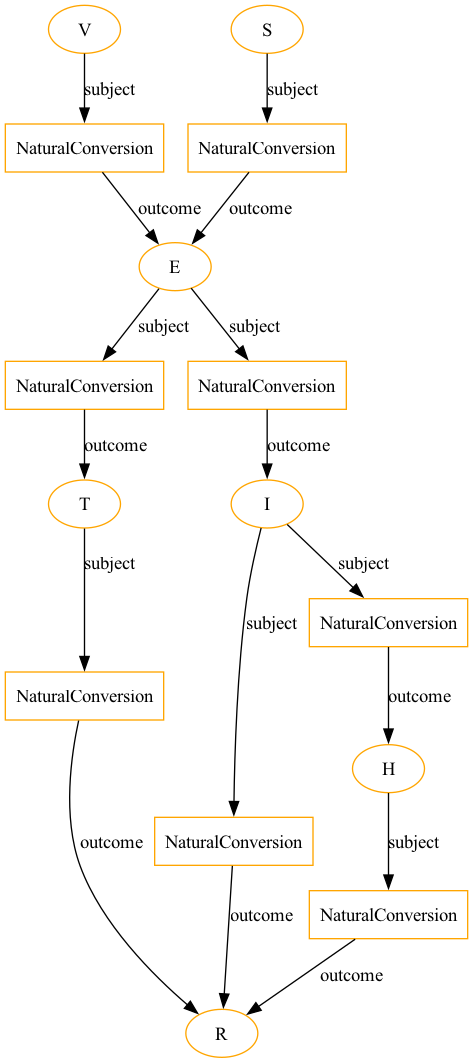

In [8]:
tm = template_model_from_sympy_odes(odes2)
tm.draw_jupyter()

In [9]:
# Define variables
t = sympy.symbols('t')
S_f, V_a, I_f, P, C, R_f, S_m, I_m, R_m = sympy.symbols(r"S_f V_a I_f P C R_f S_m I_m R_m", cls = sympy.Function)

# Define parameters
N_f, N_m, lambda_f, lambda_m, pi_f, pi_m, beta_f, beta_m, \
d_f, d_m, sigma_f, sigma_m, delta, theta, phi, varepsilon, \
omega, eta, xi, mu_f, mu_m = \
sympy.symbols(r'N_f N_m lambda_f lambda_m pi_f pi_m beta_f beta_m '
              r'd_f d_m sigma_f sigma_m delta theta phi varepsilon '
              r'omega eta xi mu_f mu_m')

# Define the differential equations
odes3 = [
    sympy.Eq(S_f(t).diff(t), omega * V_a(t) - phi * S_f(t)
        - (1 / N_m) * d_f * beta_m * I_m(t) * S_f(t)),
    sympy.Eq(V_a(t).diff(t), phi * S_f(t) - omega * V_a(t) 
        - (1 / N_m) * d_f * beta_m * I_m(t) * (1 - varepsilon) * V_a(t)),
    sympy.Eq(I_f(t).diff(t), (1 / N_m) * d_f * beta_m * I_m(t) * S_f(t) 
        + (1 / N_m) * d_f * beta_m * I_m(t) * (1 - varepsilon) * V_a(t) - delta * I_f(t) - mu_f * I_f(t)),
    sympy.Eq(P(t).diff(t), delta * I_f(t) - theta * P(t) - xi * P(t)),
    sympy.Eq(C(t).diff(t), theta * P(t)),
    sympy.Eq(R_f(t).diff(t), mu_f * I_f(t) + xi * P(t)),
    sympy.Eq(S_m(t).diff(t), -I_f(t) * S_m(t) * (1 / N_f) * d_m * beta_f
        - P(t) * S_m(t) * (1 / N_f) * d_m * beta_f * eta),
    sympy.Eq(I_m(t).diff(t), I_f(t) * S_m(t) * (1 / N_f) * d_m * beta_f
        + P(t) * S_m(t) * (1 / N_f) * d_m * beta_f * eta - mu_m * I_m(t)),
    sympy.Eq(R_m(t).diff(t), mu_m * I_m(t))
]


In [10]:
tm = template_model_from_sympy_odes(odes3)

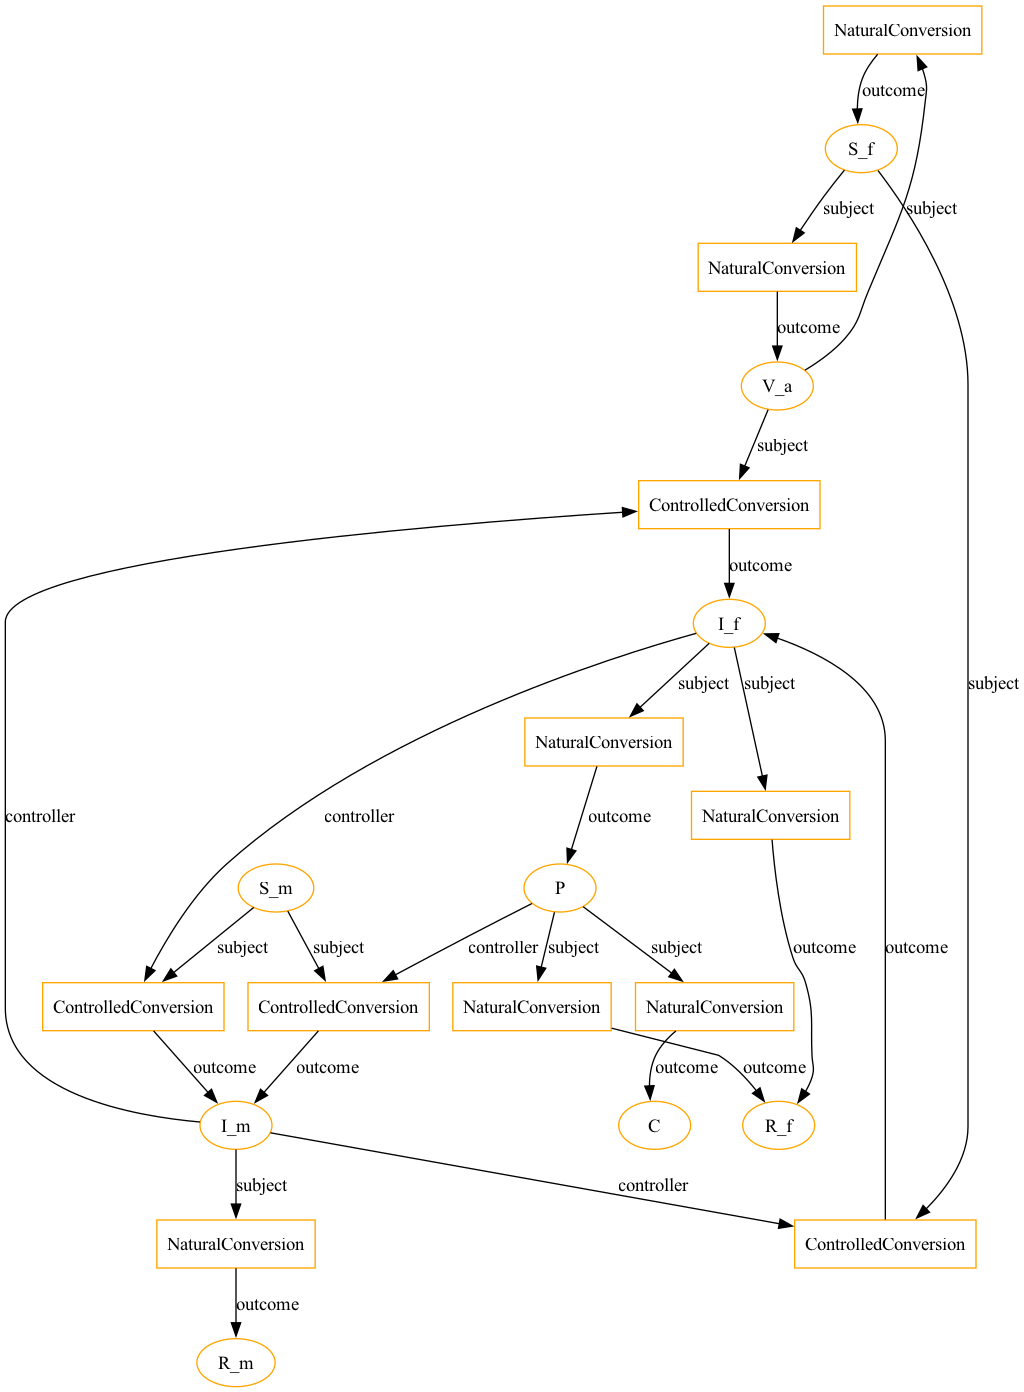

In [11]:
tm.draw_jupyter()

In [12]:
for t in tm.templates:
    print(t.rate_law)

V_a*omega
S_f*phi
I_m*S_f*beta_m*d_f/N_m
I_m*V_a*beta_m*d_f*(1 - varepsilon)/N_m
I_f*delta
I_f*mu_f
P*theta
P*xi
P*S_m*beta_f*d_m*eta/N_f
I_f*S_m*beta_f*d_m/N_f
I_m*mu_m


In [13]:
import sympy as sp

# Define time variable
t = sp.symbols("t")

# Define time-dependent variables
S_l, S_h, E_h, P, I1, I2, H, R_h, S_r, E_r, I_r, R_r = sp.symbols(
    "S_l S_h E_h P I1 I2 H R_h S_r E_r I_r R_r", cls=sp.Function
)

# Define the parameters with spelled-out names
pi_h, rho, nu, lambda_h, mu_h, sigma_h, omega, theta, k1, k2, tau1, tau2, tau3, delta_h, pi_r, lambda_r, mu_r, sigma_r, delta_r, tau_r = sp.symbols(
    "pi_h rho nu lambda_h mu_h sigma_h omega theta k1 k2 tau1 tau2 tau3 delta_h pi_r lambda_r mu_r sigma_r delta_r tau_r"
)

# Define the system of ODEs
odes4 = [
    sp.Eq(S_l(t).diff(t), pi_h * (1 - rho) - nu * lambda_h * S_l(t) - mu_h * S_l(t)),
    sp.Eq(S_h(t).diff(t), pi_h * rho - lambda_h * S_h(t) - mu_h * S_h(t)),
    sp.Eq(E_h(t).diff(t), (nu * S_l(t) + S_h(t)) * lambda_h - (sigma_h + mu_h) * E_h(t)),
    sp.Eq(P(t).diff(t), sigma_h * E_h(t) - (omega + mu_h) * P(t)),
    sp.Eq(I1(t).diff(t), omega * P(t) - (theta + k1 + tau1 + mu_h) * I1(t)),
    sp.Eq(I2(t).diff(t), theta * I1(t) - (k2 + delta_h + tau2 + mu_h) * I2(t)),
    sp.Eq(H(t).diff(t), k1 * I1(t) + k2 * I2(t) - (delta_h + tau3 + mu_h) * H(t)),
    sp.Eq(R_h(t).diff(t), tau1 * I1(t) + tau2 * I2(t) + tau3 * H(t) - mu_h * R_h(t)),
    sp.Eq(S_r(t).diff(t), pi_r - lambda_r * S_r(t) - mu_r * S_r(t)),
    sp.Eq(E_r(t).diff(t), lambda_r * S_r(t) - (sigma_r + mu_r) * E_r(t)),
    sp.Eq(I_r(t).diff(t), sigma_r * E_r(t) - (delta_r + tau_r + mu_r) * I_r(t)),
    sp.Eq(R_r(t).diff(t), tau_r * I_r(t) - mu_r * R_r(t)),
]


In [14]:
tm = template_model_from_sympy_odes(odes4)

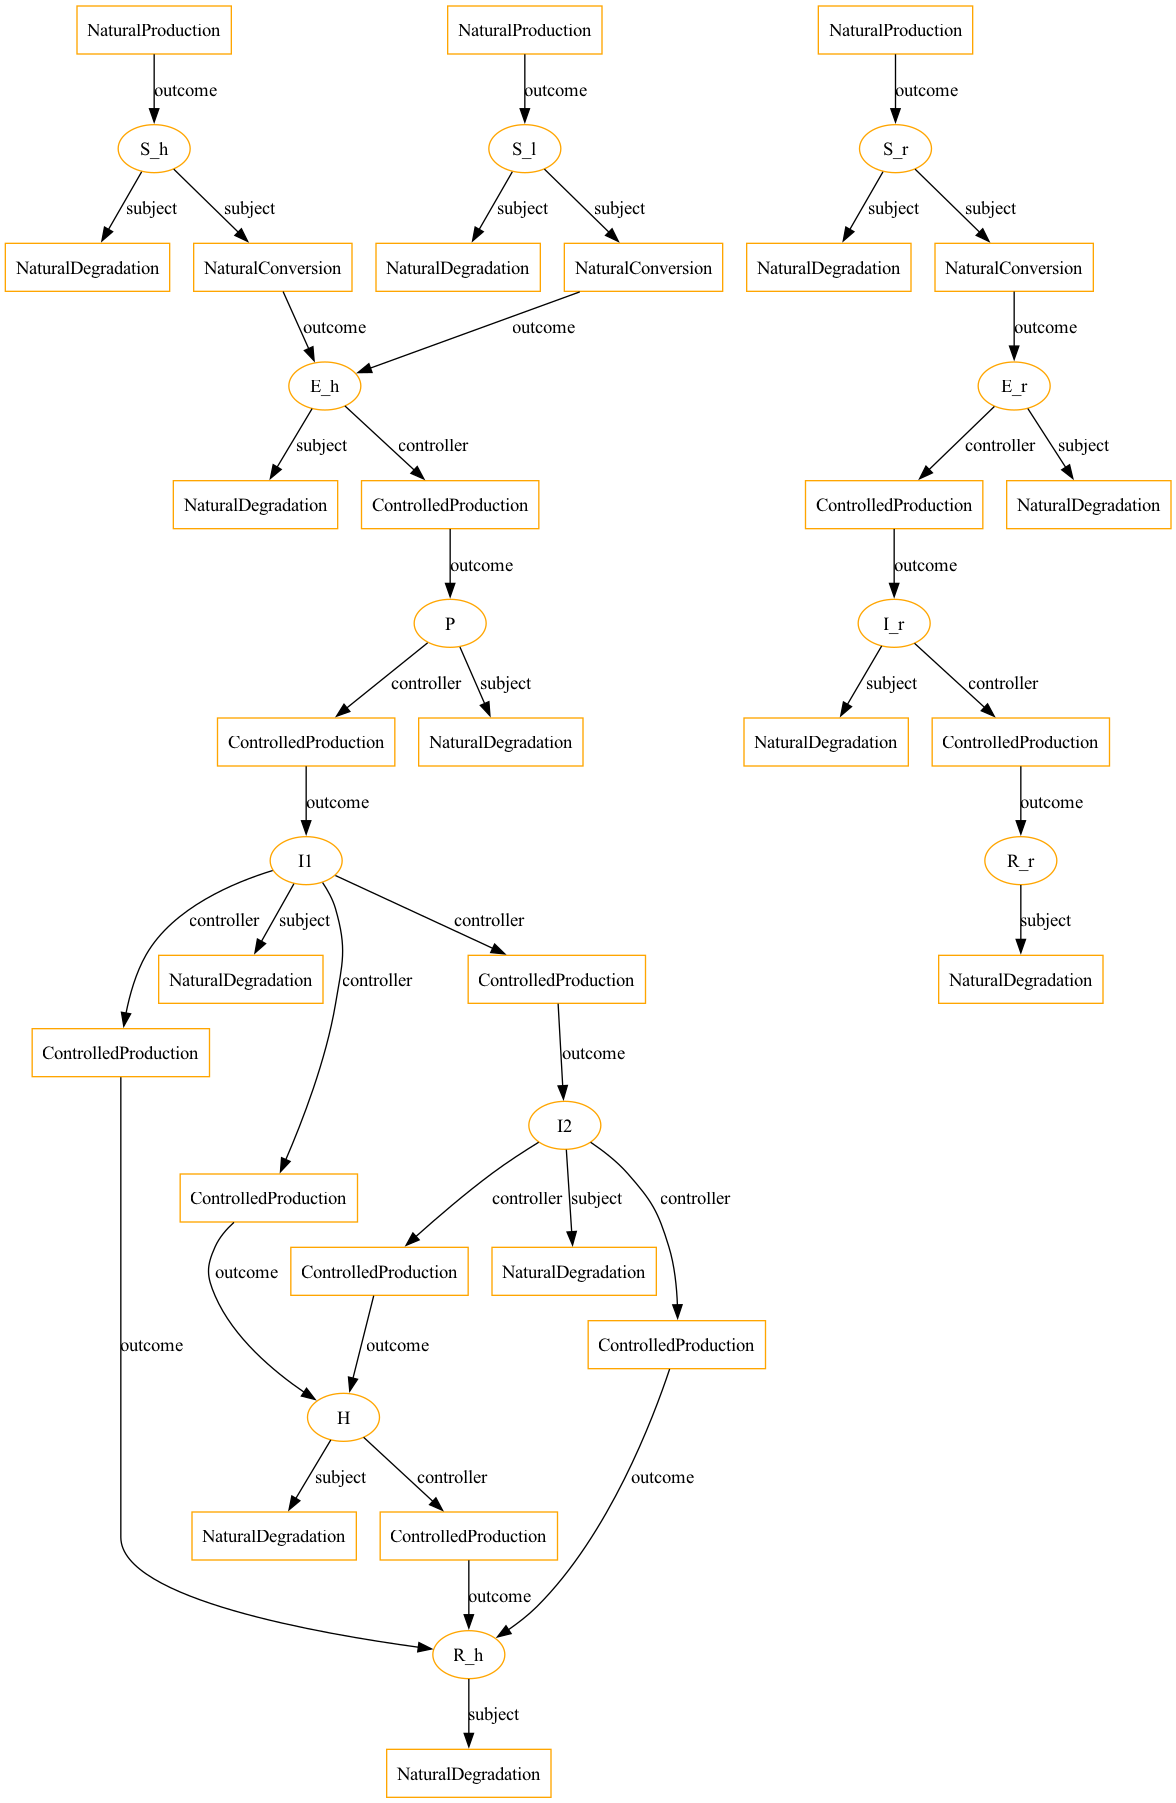

In [15]:
tm.draw_jupyter()